In [3]:
# Import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load dataset
ecommerce = pd.read_csv('Ecommerce Customers.csv')

print("Dataset loaded successfully!")
print(f"Shape: {ecommerce.shape}")

Dataset loaded successfully!
Shape: (500, 8)


In [5]:
print("First 5 rows of the dataset:")
print(ecommerce.head())

First 5 rows of the dataset:
                           Email  \
0      mstephenson@fernandez.com   
1              hduke@hotmail.com   
2               pallen@yahoo.com   
3        riverarebecca@gmail.com   
4  mstephens@davidson-herman.com   

                                             Address            Avatar  \
0       835 Frank Tunnel\nWrightmouth, MI 82180-9605            Violet   
1     4547 Archer Common\nDiazchester, CA 06566-8576         DarkGreen   
2  24645 Valerie Unions Suite 582\nCobbborough, D...            Bisque   
3   1414 David Throughway\nPort Jason, OH 22070-1220       SaddleBrown   
4  14023 Rodriguez Passage\nPort Jacobville, PR 3...  MediumAquaMarine   

   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543 

In [6]:
print("\nDataset Info:")
print(ecommerce.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None


In [7]:
print("\nStatistical Summary:")
print(ecommerce.describe())


Statistical Summary:
       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152        33.913847   
25%              32.341822    11.388153        36.349257   
50%              33.082008    11.983231        37.069367   
75%              33.711985    12.753850        37.716432   
max              36.139662    15.126994        40.005182   

       Length of Membership  Yearly Amount Spent  
count            500.000000           500.000000  
mean               3.533462           499.314038  
std                0.999278            79.314782  
min                0.269901           256.670582  
25%                2.930450           445.038277  
50%                3.533975           498.887875  
75%                4.126502           549.313828  
max                6.922689  

In [8]:
print("\nMissing Values:")
print(ecommerce.isnull().sum())


Missing Values:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [9]:
print("\nColumn Names:")
print(ecommerce.columns.tolist())


Column Names:
['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']


In [10]:
#duplicates
duplicates = ecommerce.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    ecommerce = ecommerce.drop_duplicates()
    print(f"Removed {duplicates} duplicates. New shape: {ecommerce.shape}")

if ecommerce.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    # For numerical columns, fill with median
    num_cols = ecommerce.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        ecommerce[col].fillna(ecommerce[col].median(), inplace=True)
    
    cat_cols = ecommerce.select_dtypes(include=['object']).columns
    for col in cat_cols:
        ecommerce[col].fillna(ecommerce[col].mode()[0], inplace=True)
    print("Missing values handled.")
else:
    print("\nNo missing values found!")

Number of duplicate rows: 0

No missing values found!


In [25]:
print("\nColumns to analyze:")
for col in ecommerce.columns:
    print(f"  - {col}")

columns_to_drop = []
for col in ecommerce.columns:
    if ecommerce[col].dtype == 'object' and col.lower() not in ['yearly amount spent', 'yearly_amount_spent']:
        columns_to_drop.append(col)

if columns_to_drop:
    print(f"\nDropping non-numeric columns: {columns_to_drop}")
    ecommerce_numeric = ecommerce.drop(columns=columns_to_drop)
else:
    ecommerce_numeric = ecommerce.copy()

print(f"\nNumeric DataFrame shape: {ecommerce_numeric.shape}")
print("Numeric columns:", ecommerce_numeric.columns.tolist())


Columns to analyze:
  - Email
  - Address
  - Avatar
  - Avg. Session Length
  - Time on App
  - Time on Website
  - Length of Membership
  - Yearly Amount Spent

Dropping non-numeric columns: ['Email', 'Address', 'Avatar']

Numeric DataFrame shape: (500, 5)
Numeric columns: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']


In [13]:
target_column = None
for col in ecommerce_numeric.columns:
    if 'yearly' in col.lower() or 'amount' in col.lower() or 'spent' in col.lower():
        target_column = col
        break

if target_column is None:
    # If no obvious target column, assume the last column is the target
    target_column = ecommerce_numeric.columns[-1]
    print(f"Using '{target_column}' as target column")

print(f"\nTarget column: {target_column}")

X = ecommerce_numeric.drop(columns=[target_column])
y = ecommerce_numeric[target_column]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")


Target column: Yearly Amount Spent

Features shape: (500, 4)
Target shape: (500,)

Feature columns: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 350 samples
Testing set size: 150 samples


In [15]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Intercept: {lm.intercept_:.4f}")
print("Coefficients:")
for feature, coef in zip(X.columns, lm.coef_):
    print(f"  {feature}: {coef:.4f}")

Model trained successfully!
Intercept: -1047.9328
Coefficients:
  Avg. Session Length: 25.9815
  Time on App: 38.5902
  Time on Website: 0.1904
  Length of Membership: 61.2791


In [16]:
predictions = lm.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
print("\nFirst 10 predictions vs actual values:")
print(comparison.head(10))


First 10 predictions vs actual values:
         Actual   Predicted
18   452.315675  456.441861
361  401.033135  402.720053
104  410.069611  409.253154
4    599.406092  591.431034
156  586.155870  590.014373
350  535.480775  548.823966
32   588.712606  577.597380
205  712.396327  715.444281
81   462.897636  473.789345
414  532.724805  545.921136


In [17]:
from sklearn import metrics
import numpy as np

MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = np.sqrt(MSE)

print("\n=== Model Performance Metrics ===")
print(f"Mean Absolute Error (MAE): ${MAE:.2f}")
print(f"Mean Squared Error (MSE): ${MSE:.2f}")
print(f"Root Mean Squared Error (RMSE): ${RMSE:.2f}")


=== Model Performance Metrics ===
Mean Absolute Error (MAE): $7.23
Mean Squared Error (MSE): $79.81
Root Mean Squared Error (RMSE): $8.93


In [18]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print(f"R-squared Score: {r2:.4f}")
print(f"Accuracy: {r2 * 100:.2f}%")

R-squared Score: 0.9890
Accuracy: 98.90%


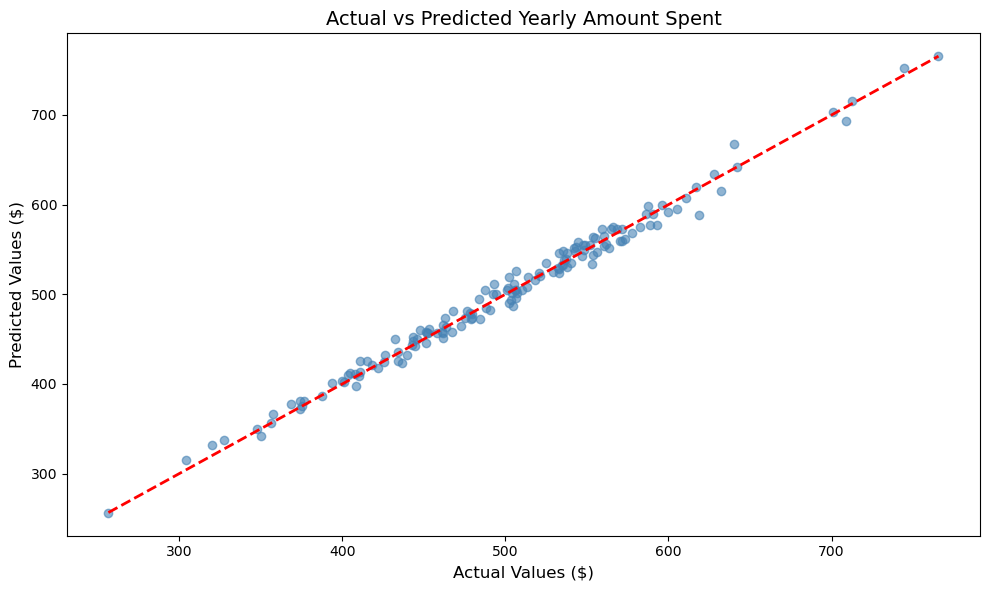

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values ($)', fontsize=12)
plt.ylabel('Predicted Values ($)', fontsize=12)
plt.title('Actual vs Predicted Yearly Amount Spent', fontsize=14)
plt.tight_layout()
plt.show()

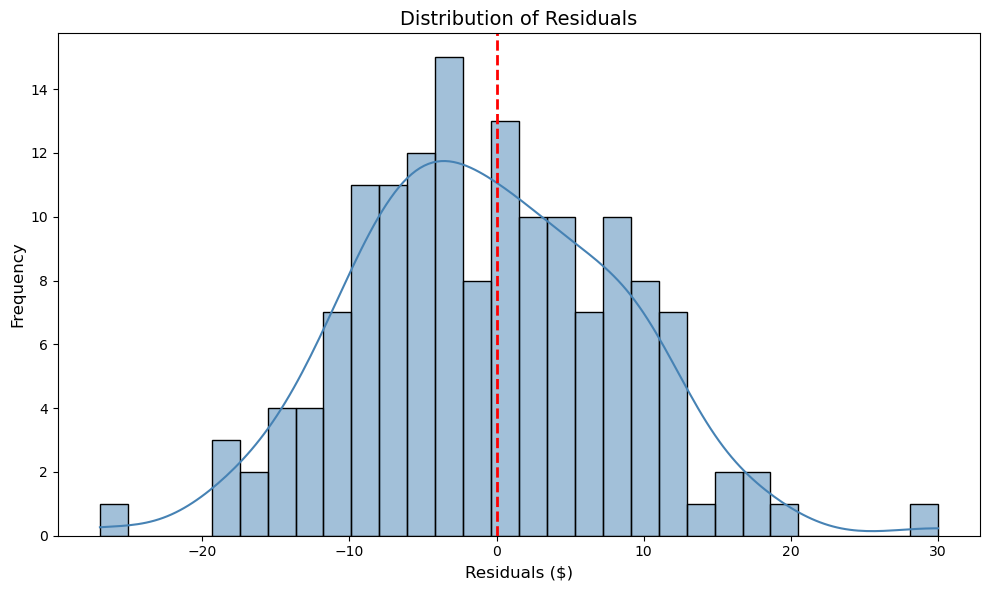

In [20]:
residuals = y_test - predictions

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.xlabel('Residuals ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

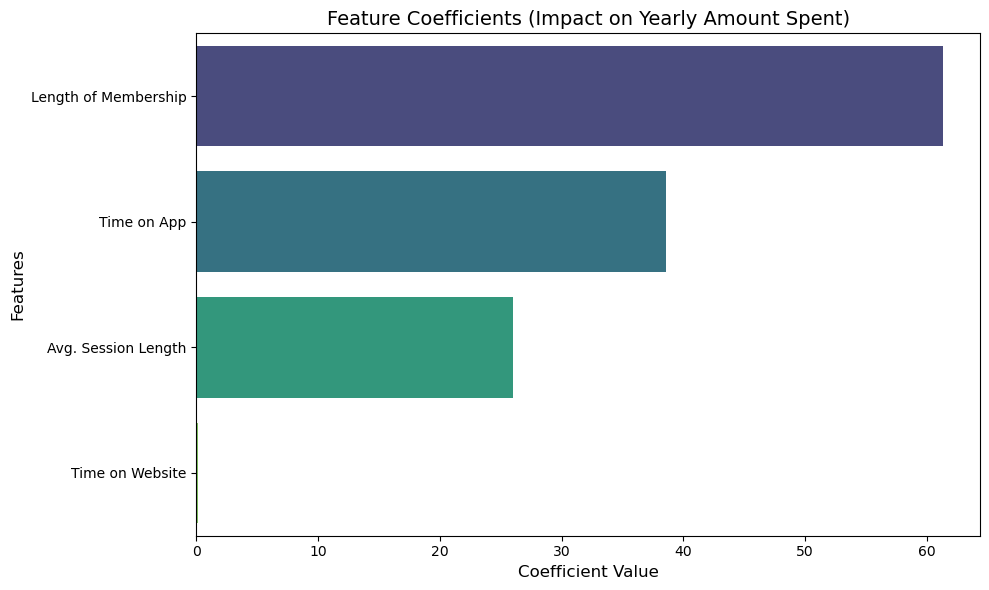

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lm.coef_
})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='viridis')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Coefficients (Impact on Yearly Amount Spent)', fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

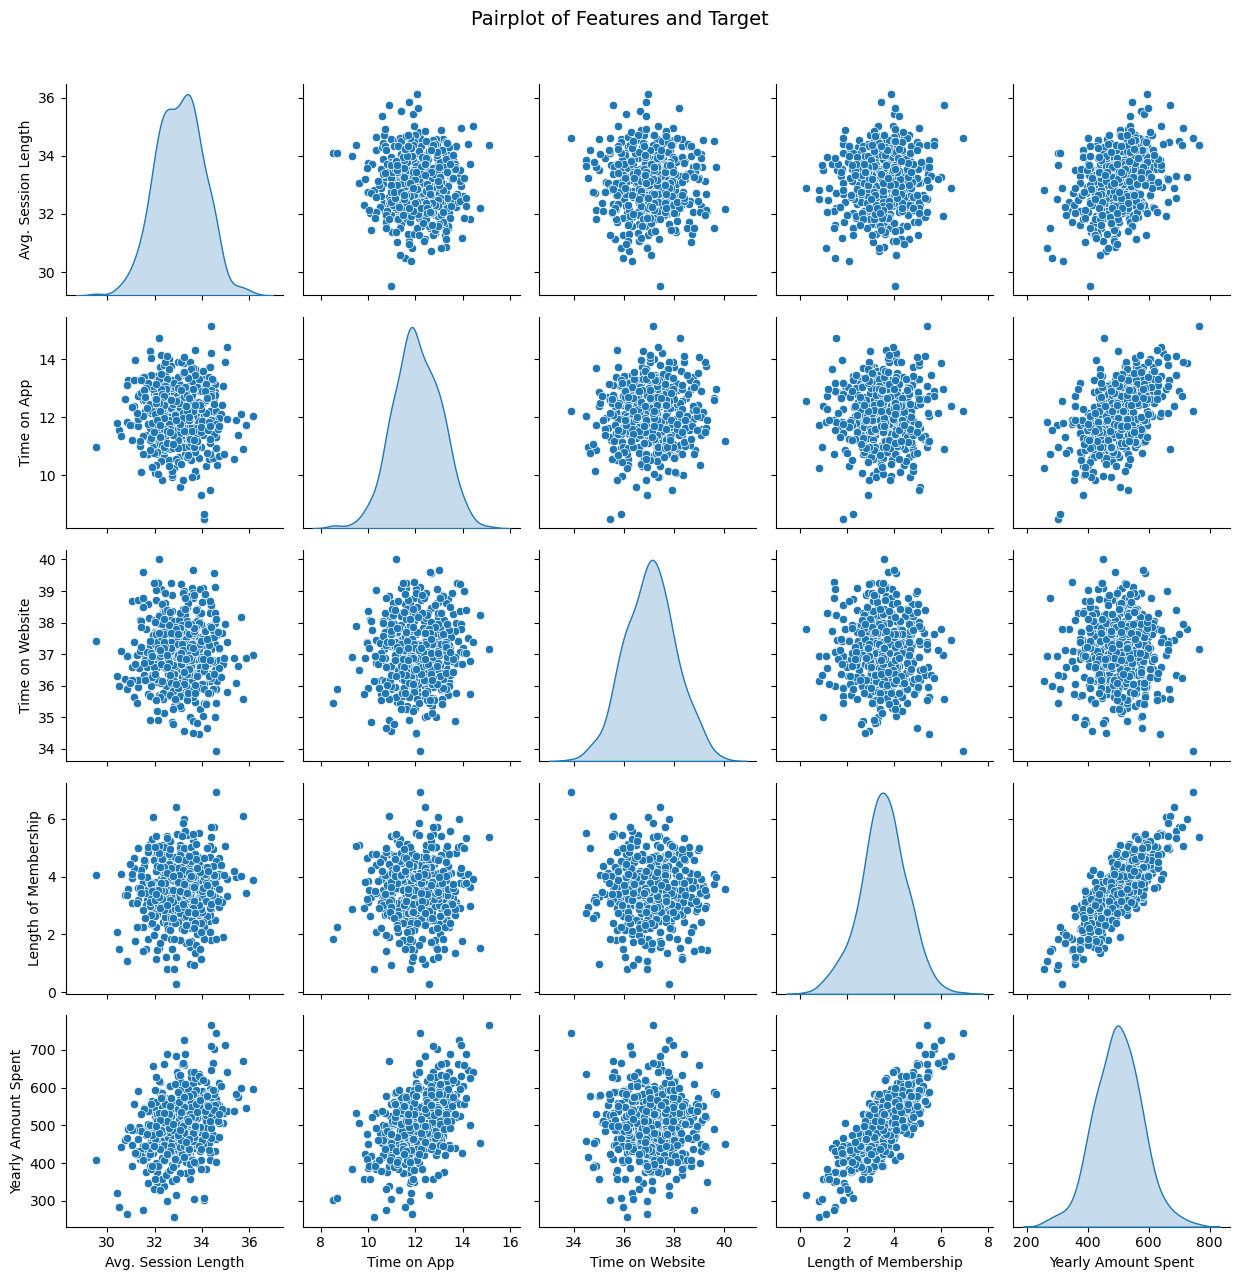

In [22]:
selected_features = X.columns.tolist()
selected_features.append(target_column)

plt.figure(figsize=(12, 10))
sns.pairplot(ecommerce_numeric[selected_features], diag_kind='kde')
plt.suptitle('Pairplot of Features and Target', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

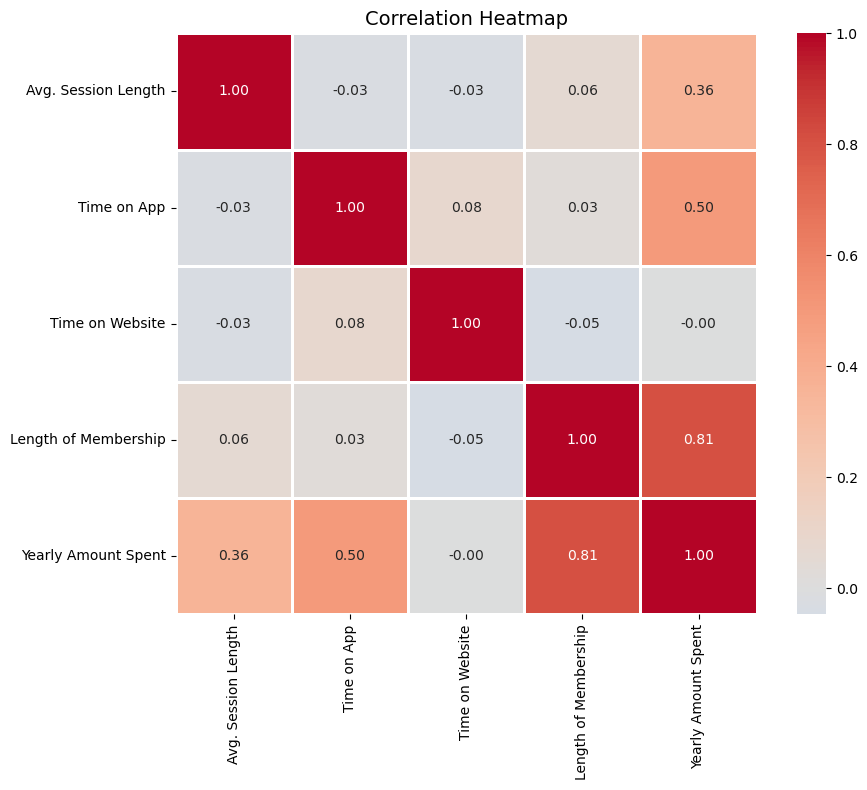

In [23]:
plt.figure(figsize=(10, 8))
correlation_matrix = ecommerce_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.22814865343082
MSE: 79.81305165097437
RMSE: 8.93381506697863


In [24]:
print("\n" + "="*60)
print("LINEAR REGRESSION MODEL - SUMMARY REPORT")
print("="*60)

print("\n DATASET INFORMATION:")
print(f"  - Total samples: {len(ecommerce)}")
print(f"  - Features used: {len(X.columns)}")
print(f"  - Feature names: {', '.join(X.columns)}")
print(f"  - Target variable: {target_column}")

print("\n MODEL PERFORMANCE:")
print(f"  - R-squared Score: {r2:.4f} ({r2*100:.2f}%)")
print(f"  - Mean Absolute Error (MAE): ${MAE:.2f}")
print(f"  - Root Mean Squared Error (RMSE): ${RMSE:.2f}")

print("\n KEY INSIGHTS:")

if len(feature_importance) > 0:
    most_positive = feature_importance.iloc[0]
    most_negative = feature_importance.iloc[-1]
    
    if most_positive['Coefficient'] > 0:
        print(f"  - '{most_positive['Feature']}' has the strongest POSITIVE influence")
        print(f"    (1 unit increase → ${most_positive['Coefficient']:.2f} increase in spending)")
    
    if most_negative['Coefficient'] < 0:
        print(f"  - '{most_negative['Feature']}' has the strongest NEGATIVE influence")
        print(f"    (1 unit increase → ${abs(most_negative['Coefficient']):.2f} decrease in spending)")

print("\n FEATURE CORRELATION WITH TARGET:")
if target_column in ecommerce_numeric.columns:
    correlations = ecommerce_numeric.corr()[target_column].sort_values(ascending=False)
    for feature, corr in correlations.items():
        if feature != target_column:
            print(f"  - {feature}: {corr:.4f}")

print("\n" + "="*60)
print(" Linear Regression model successfully trained and evaluated!")
print("="*60)


LINEAR REGRESSION MODEL - SUMMARY REPORT

 DATASET INFORMATION:
  - Total samples: 500
  - Features used: 4
  - Feature names: Avg. Session Length, Time on App, Time on Website, Length of Membership
  - Target variable: Yearly Amount Spent

 MODEL PERFORMANCE:
  - R-squared Score: 0.9890 (98.90%)
  - Mean Absolute Error (MAE): $7.23
  - Root Mean Squared Error (RMSE): $8.93

 KEY INSIGHTS:
  - 'Length of Membership' has the strongest POSITIVE influence
    (1 unit increase → $61.28 increase in spending)

 FEATURE CORRELATION WITH TARGET:
  - Length of Membership: 0.8091
  - Time on App: 0.4993
  - Avg. Session Length: 0.3551
  - Time on Website: -0.0026

 Linear Regression model successfully trained and evaluated!
